In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
iris = pd.read_csv('iris.csv')
iris

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [24]:
df.isnull().sum()

sepal.length    0
sepal.width     0
petal.length    0
petal.width     0
variety         0
dtype: int64

In [25]:
categories = df['variety'].unique()

In [28]:
#Labélisation des données.
S = {'variety':
      {categories[0]:0,
      categories[1]:1,
      categories[2]:2}}
df.replace(S,inplace=True)
df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [29]:
#Partie train-val-test
x = df[['sepal.length','sepal.width','petal.length','petal.width']].values
y = df['variety'].values

In [30]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.1)

xtrain,xval,ytrain,yval= train_test_split(xtrain,ytrain,test_size=0.2)

In [31]:
from sklearn.preprocessing import StandardScaler
# Créer un objet StandardScaler
scaler = StandardScaler()

In [32]:
# Adapter le scaler aux données d'entraînement et transformer les données d'entraînement
xtrain = scaler.fit_transform(xtrain)

# Utiliser le même scaler pour standardiser les données de validation et de test
xval = scaler.transform(xval)
xtest = scaler.transform(xtest)

## LE DNN : Deep Neural Network

In [36]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense,Activation

model = tf.keras.Sequential()
model.add(Input(shape=(4,)))
model.add(Dense(units=32,activation='relu'))
model.add(Dense(units=32,activation='relu'))
model.add(Dense(units=3,activation='softmax'))
model.summary()
#Compiler le modéle.
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,315 (5.14 KB)

 Trainable params: 1,315 (5.14 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.fit(xtrain,ytrain,batch_size=15,epochs=50,validation_data=(xval,yval))

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.2152 - loss: 1.1593 - val_accuracy: 0.1481 - val_loss: 1.0700
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1219 - loss: 1.0682 - val_accuracy: 0.4444 - val_loss: 1.0021
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5435 - loss: 1.0004 - val_accuracy: 0.7778 - val_loss: 0.9427
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6887 - loss: 0.9459 - val_accuracy: 0.7407 - val_loss: 0.8874
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6932 - loss: 0.8811 - val_accuracy: 0.7778 - val_loss: 0.8325
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7755 - loss: 0.8147 - val_accuracy: 0.7407 - val_loss: 0.7770
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7992 - loss: 0.7396 - val_accuracy: 0.7407 - val_loss: 0.7189
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7928 - loss: 0.6731 - val_accuracy: 0.7778 - val_loss: 0.6610
Epoch 9

In [38]:
import matplotlib.pyplot as plt

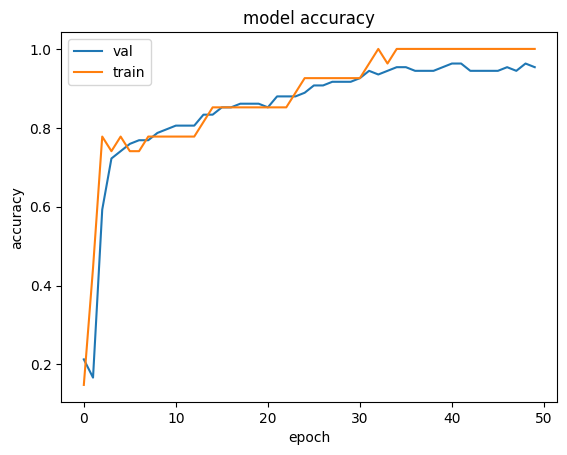

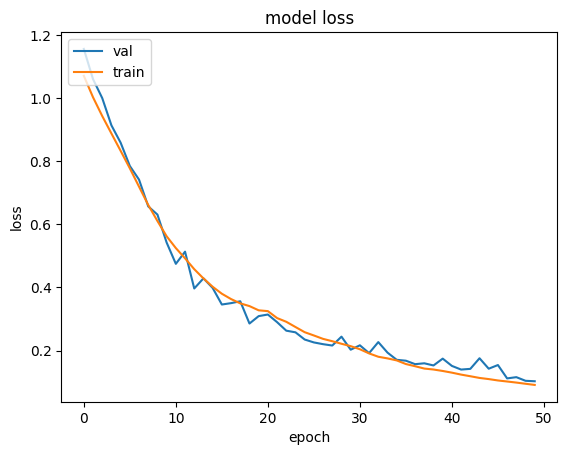

In [39]:
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['val','train'], loc='upper left')
plt.show()

plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['val','train'], loc='upper left')
plt.show()

In [41]:
#Partie Finale : prédiction
import numpy as np
from sklearn.metrics import confusion_matrix,classification_report

predictions = model.predict(xtest)
print(predictions[0])

#Un exemple avec la matrice de confusion
test_pred = [np.argmax(predictions[i]) for i in range(len(predictions))]

matriceConfusion = confusion_matrix(ytest,test_pred)

print(matriceConfusion)
for i in range(10):
  print("predicted : {}, actual class : {} ".format(np.argmax(predictions[i]),ytest[i]))

predictions[5]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
[2.1610498e-05 1.1426918e-02 9.8855150e-01]
[[1 0 0]
 [0 7 0]
 [0 0 7]]
predicted : 2, actual class : 2 
predicted : 2, actual class : 2 
predicted : 0, actual class : 0 
predicted : 1, actual class : 1 
predicted : 2, actual class : 2 
predicted : 1, actual class : 1 
predicted : 1, actual class : 1 
predicted : 2, actual class : 2 
predicted : 2, actual class : 2 
predicted : 1, actual class : 1 


array([0.00413684, 0.9344046 , 0.0614586 ], dtype=float32)